# Experiments notebook

## Imports

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.ML.config import FULL_FEATURES, RANDOM_STATE, TEST_SIZE, CV_FOLDS,EXCLUDED,TARGET,WEARABLE_FEATURES
from src.ML.pipelines import create_LR_pipeline, create_RF_pipeline, create_SVR_pipeline,create_XGBOOST_pipeline
from src.ML.evaluation import *
from src.ML.visualization import *
from src.ML.io_utils import *
from src.ML.tunning import tune_RF, tune_SVR,tune_XGBOOST
from sklearn.decomposition import PCA

csv_address= os.path.abspath(os.path.join(os.getcwd(), "..", "Features", "all_subjects_features.csv"))

## Load data/Generate random data

In [22]:
from sklearn.model_selection import train_test_split

"""
def make_random_data(n_samples=200):
    X=pd.DataFrame(
        np.random.randn(n_samples,len(FULL_FEATURES)),
                        columns=FULL_FEATURES
    )
    y=np.random.uniform(0,10,n_samples)
    return X,y

x,y=make_random_data()
"""
x,y=load_data(csv_path=csv_address,target_name=TARGET,exclude_cols=EXCLUDED,feature_cols=WEARABLE_FEATURES,covas_threshold=5.0)
FULL_FEATURES=x.columns

X=x
print(X.head())

Original shape: (7456, 108)
NaNs per column:
                     nan_count   nan_pct
emg_high_band_power        143  1.917918
emg_hl_ratio               143  1.917918
emg_skew                   143  1.917918
emg_kurt                   143  1.917918
emg_median_freq            143  1.917918
emg_low_band_power         143  1.917918
emg_total_power            143  1.917918
emg_mean_freq              143  1.917918

Total Nans in dataset: 1144
Rows with at least one Nan: 143
New shape: (1786, 108)
    subject_idx  ecg_mean   ecg_std   ecg_min   ecg_max  ecg_skew  ecg_kurt  \
14            1 -0.000834  0.141460 -0.606951  0.421331 -1.088959  4.248976   
18            1  0.001224  0.142797 -0.624414  0.440203 -1.062581  4.229923   
21            1 -0.000543  0.139680 -0.606387  0.415914 -1.085518  4.412175   
22            1  0.000011  0.139835 -0.616710  0.450283 -1.047016  4.673673   
25            1 -0.000717  0.138335 -0.607243  0.434206 -0.896625  4.172912   

    ecg_hr_bpm  ecg_rr_mean

## Correlation with target!

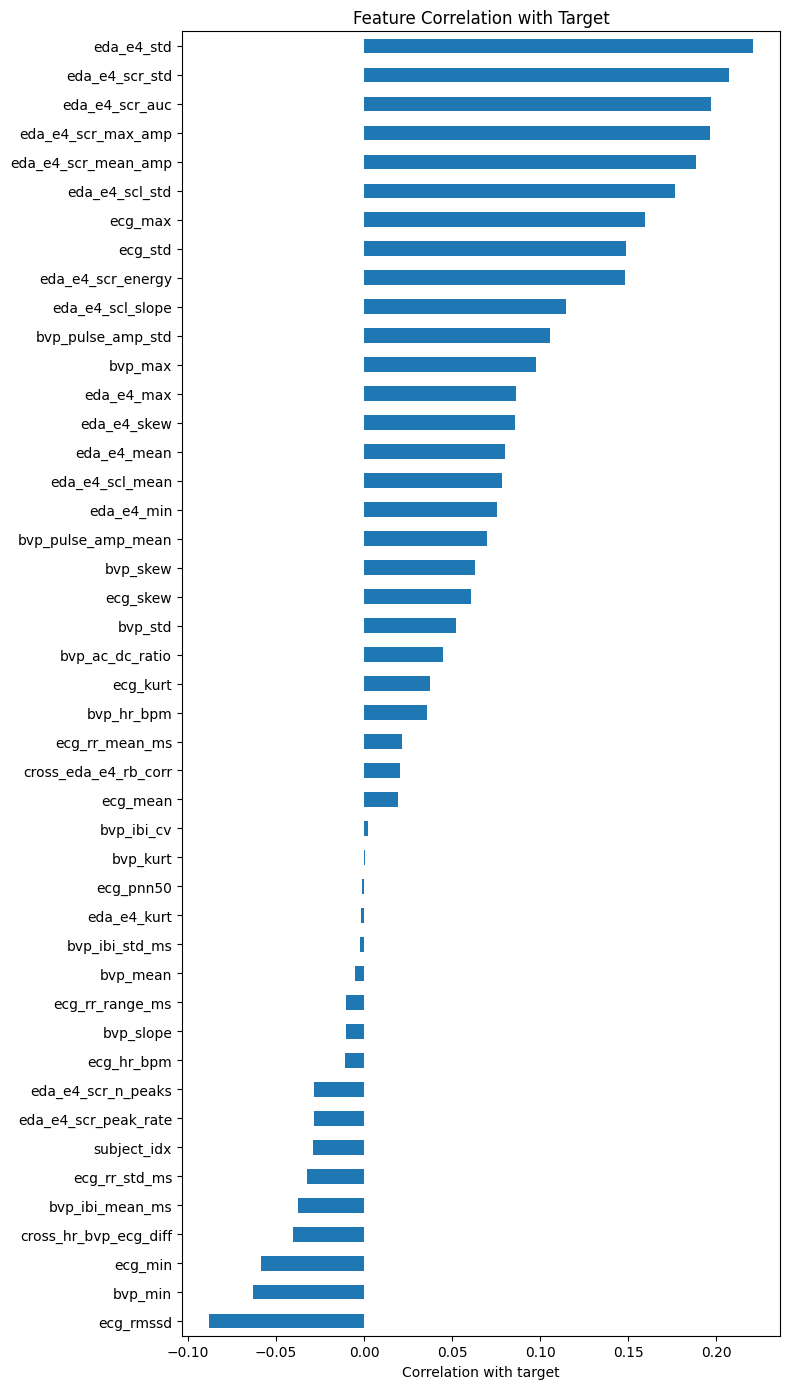

In [23]:
plot_corr_with_target(x, y)

In [14]:
import pandas as pd
import numpy as np

def filter_features_by_target_corr(X, y, threshold=0.05, return_info=False):
    """
    Remove columns from X whose absolute Pearson correlation with y is < threshold
    or whose correlation is NaN.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series, pd.DataFrame, np.ndarray, or list
        Target vector.
    threshold : float, default=0.05
        Minimum absolute correlation required to keep a feature.
    return_info : bool, default=False
        If True, also returns a DataFrame with correlations and keep/remove status.

    Returns
    -------
    X_filtered : pd.DataFrame
        Filtered feature matrix.
    info : pd.DataFrame, optional
        Summary table with feature, correlation, abs_correlation, and kept status.
        Only returned if return_info=True.
    """
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame.")

    # Convert y to Series
    if isinstance(y, pd.DataFrame):
        if y.shape[1] != 1:
            raise ValueError("If y is a DataFrame, it must have exactly one column.")
        y = y.iloc[:, 0]
    elif not isinstance(y, pd.Series):
        y = pd.Series(y, name="target")

    # Align indices if possible
    if len(X) != len(y):
        raise ValueError("X and y must have the same number of rows.")

    # Compute correlations column by column
    corrs = X.apply(lambda col: col.corr(y))

    # Keep only non-NaN correlations with abs(corr) >= threshold
    keep_mask = corrs.notna() & (corrs.abs() >= threshold)
    print( (corrs.abs() < threshold))
    kept_columns = corrs.index[keep_mask].tolist()

    X_filtered = X[kept_columns].copy()
    print(X_filtered.size)
    if return_info:
        info = pd.DataFrame({
            "feature": corrs.index,
            "correlation": corrs.values,
            "abs_correlation": corrs.abs().values,
            "kept": keep_mask.values
        }).sort_values("abs_correlation", ascending=False).reset_index(drop=True)

        return X_filtered, info

    return X_filtered


In [15]:
groups=x["subject_idx"] 
from sklearn.model_selection import GroupShuffleSplit

# grouped split
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()

# drop subject_idx if still present
for df_ in [X_train, X_test]:
    if "subject_idx" in df_.columns:
        df_.drop(columns=["subject_idx"], inplace=True)

# remove constant columns using train only
constant_cols = X_train.columns[X_train.nunique(dropna=False) <= 1]
print("Constant columns:", constant_cols.tolist())

X_train = X_train.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols, errors="ignore")

# now feature filtering on train only
X_train_filtered = filter_features_by_target_corr(
    X_train, y_train, threshold=0.00, return_info=False
)

selected_cols = X_train_filtered.columns.tolist()
X_test_filtered = X_test[selected_cols].copy()

print("X_train_filtered shape:", X_train_filtered.shape)
print("X_test_filtered shape:", X_test_filtered.shape)

Constant columns: ['bvp_vasomotor_power']
ecg_mean                 False
ecg_std                  False
ecg_min                  False
ecg_max                  False
ecg_skew                 False
ecg_kurt                 False
ecg_hr_bpm               False
ecg_rr_mean_ms           False
ecg_rr_std_ms            False
ecg_rmssd                False
ecg_rr_range_ms          False
ecg_pnn50                False
eda_e4_mean              False
eda_e4_std               False
eda_e4_min               False
eda_e4_max               False
eda_e4_skew              False
eda_e4_kurt              False
eda_e4_scl_mean          False
eda_e4_scl_std           False
eda_e4_scl_slope         False
eda_e4_scr_n_peaks       False
eda_e4_scr_peak_rate     False
eda_e4_scr_mean_amp      False
eda_e4_scr_max_amp       False
eda_e4_scr_std           False
eda_e4_scr_auc           False
eda_e4_scr_energy        False
bvp_mean                 False
bvp_std                  False
bvp_min                  Fal

In [16]:
groups = X["subject_idx"]
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

train_subjects = set(groups.iloc[train_idx])
test_subjects = set(groups.iloc[test_idx])

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Train subjects:", sorted(train_subjects))
print("Test subjects:", sorted(test_subjects))
print("Subject overlap:", train_subjects.intersection(test_subjects))

assert len(train_subjects.intersection(test_subjects)) == 0, "Leakage: some subjects are in both train and test!"

X_train_filtered = filter_features_by_target_corr(X_train, y_train, threshold=0.00, return_info=False)
selected_cols = X_train_filtered.columns.tolist()
X_test_filtered = X_test[selected_cols].copy()

Train rows: 2916
Test rows: 769
Train subjects: [1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 15, 16, 17, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 43, 45, 46, 47, 49, 50, 52]
Test subjects: [4, 6, 13, 14, 18, 20, 33, 42, 44, 48, 51]
Subject overlap: set()
ecg_mean                 False
ecg_std                  False
ecg_min                  False
ecg_max                  False
ecg_skew                 False
ecg_kurt                 False
ecg_hr_bpm               False
ecg_rr_mean_ms           False
ecg_rr_std_ms            False
ecg_rmssd                False
ecg_rr_range_ms          False
ecg_pnn50                False
eda_e4_mean              False
eda_e4_std               False
eda_e4_min               False
eda_e4_max               False
eda_e4_skew              False
eda_e4_kurt              False
eda_e4_scl_mean          False
eda_e4_scl_std           False
eda_e4_scl_slope         False
eda_e4_scr_n_peaks       False
eda_e4_scr_peak_rate     False


## PCA?


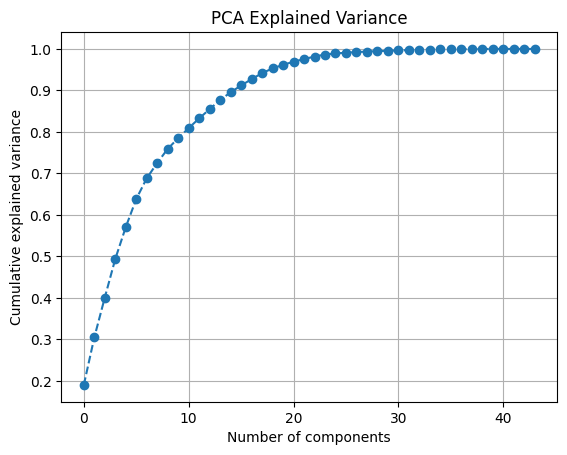

In [17]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_train_scaled)

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    linestyle='--',   
    marker='o'        #
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid(True)

plt.show()

## Run model (baseline)


In [18]:
pipeline_lr=create_LR_pipeline()
pipeline_rf=create_RF_pipeline()
pipeline_svr=create_SVR_pipeline()
pipeline_xgboost=create_XGBOOST_pipeline()

metrics_lr,y_pred_lr=train_and_evaluate(pipeline_lr, X_train, y_train, X_test, y_test)
metrics_rf,y_pred_rf=train_and_evaluate(pipeline_rf, X_train, y_train, X_test, y_test)
metrics_svr,y_pred_svr=train_and_evaluate(pipeline_svr, X_train, y_train, X_test, y_test)
metrics_xgboost,y_pred_xgboost=train_and_evaluate(pipeline_xgboost,X_train,y_train,X_test,y_test)

print("LR Metrics:", metrics_lr)
print("RF Metrics:", metrics_rf)
print("SVR Metrics:", metrics_svr)
print("XGBOOST:",metrics_xgboost)

LR Metrics: {'MSE': 874.4944350509971, 'R2': -0.020217753892327606, 'RMSE': np.float64(29.571852073399075), 'MAE': 24.901209318520824}
RF Metrics: {'MSE': 840.6873923422916, 'R2': 0.019222800324585232, 'RMSE': np.float64(28.994609711846294), 'MAE': 24.849982228001732}
SVR Metrics: {'MSE': 857.252449857785, 'R2': -0.00010261227288688168, 'RMSE': np.float64(29.278873780556946), 'MAE': 25.4102613813764}
XGBOOST: {'MSE': 930.3385406475102, 'R2': -0.0853675658250681, 'RMSE': np.float64(30.501451451488503), 'MAE': 25.317617942452898}


In [19]:
test_groups = groups.iloc[test_idx].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Make y_pred a Series too, so boolean masking is aligned cleanly
y_pred_reset = pd.Series(y_pred_xgboost).reset_index(drop=True)

# Sanity checks
assert len(test_groups) == len(y_test_reset) == len(y_pred_reset), \
    "Lengths of test_groups, y_test, and y_pred do not match."

results = []

for subject in sorted(test_groups.unique()):
    mask = test_groups == subject

    y_true_subj = y_test_reset.loc[mask]
    y_pred_subj = y_pred_reset.loc[mask]

    metrics = calculate_metrics(y_true_subj, y_pred_subj)

    results.append({
        "subject_idx": subject,
        "n_windows": int(mask.sum()),
        "R2": metrics["R2"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "MSE": metrics["MSE"],
    })

per_subject_df = pd.DataFrame(results).sort_values("subject_idx").reset_index(drop=True)
print(per_subject_df)

    subject_idx  n_windows        R2        MAE       RMSE          MSE
0             4         50 -1.174182  25.853166  30.917695   955.903841
1             6         79 -0.127642  21.910348  26.371126   695.436296
2            13         57 -0.731328  30.549565  34.494188  1189.848994
3            14         67 -1.407852  31.124010  35.293323  1245.618646
4            18         60  0.304343  15.188143  19.217399   369.308417
5            20        120  0.122958  21.623889  26.773039   716.795617
6            33         57 -0.597772  27.912510  33.065877  1093.352241
7            42         79 -0.573215  34.550847  40.205737  1616.501290
8            44         62 -0.209414  28.437049  33.131267  1097.680834
9            48         82 -0.168374  23.171379  27.617718   762.738360
10           51         56 -0.352925  20.164344  24.134452   582.471795


In [20]:
results = []
results.append({"Model": "Linear Regression", **metrics_lr})
results.append({"Model": "Random Forest", **metrics_rf})
results.append({"Model": "SVR", **metrics_svr})
results.append({"Model": "XGBoost", **metrics_xgboost})
results_df = pd.DataFrame(results)
results_df

,Model,MSE,R2,RMSE,MAE
0,Linear Regression,874.494435,-0.020218,29.571852,24.901209
1,Random Forest,840.687392,0.019223,28.994610,24.849982
2,SVR,857.252450,-0.000103,29.278874,25.410261
3,XGBoost,930.338541,-0.085368,30.501451,25.317618


## PLOTS

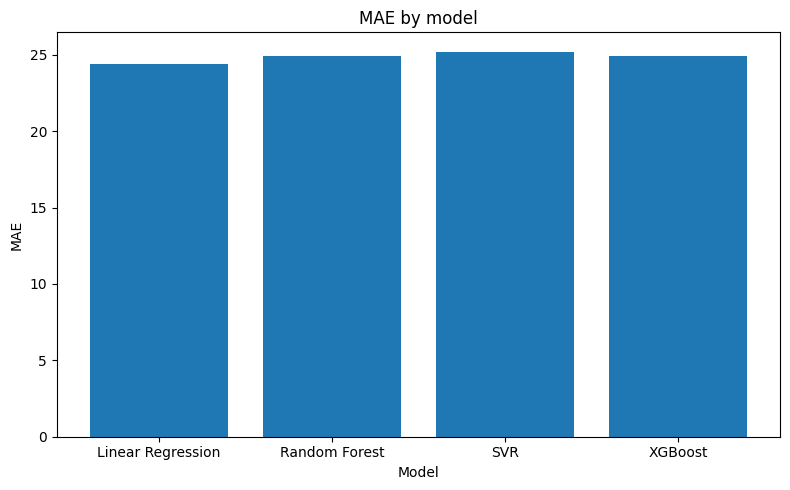

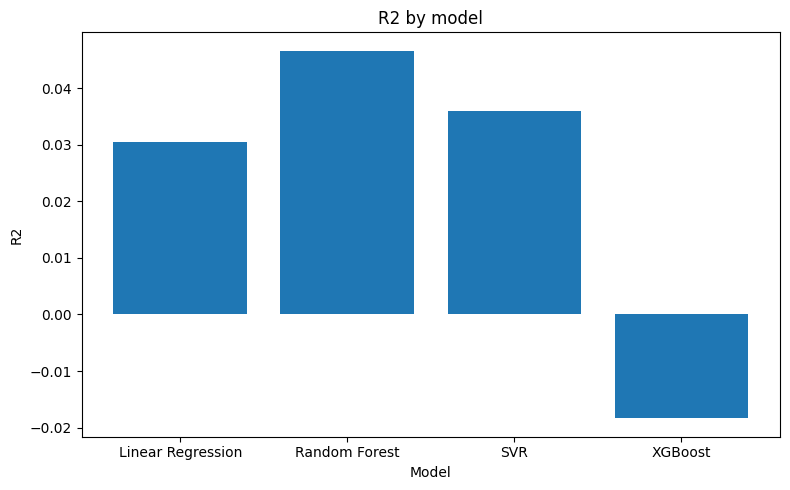

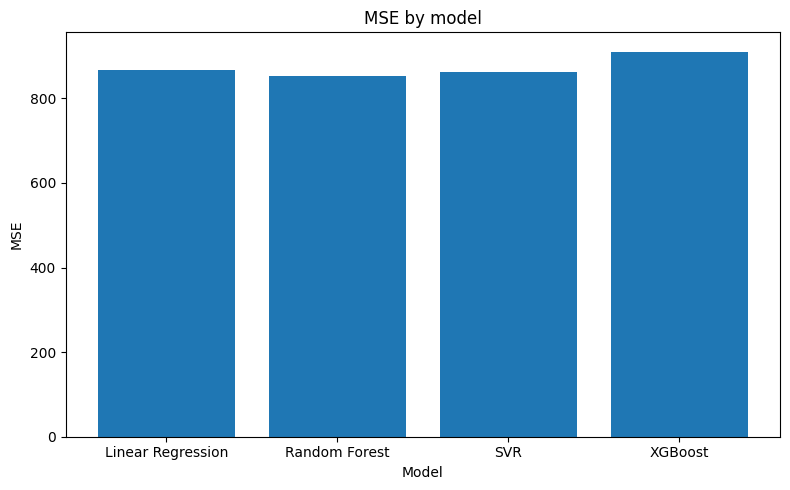

In [ ]:
plot_metric_by_model(results_df, metric="MAE")
plot_metric_by_model(results_df, metric="R2")
plot_metric_by_model(results_df, metric="MSE")

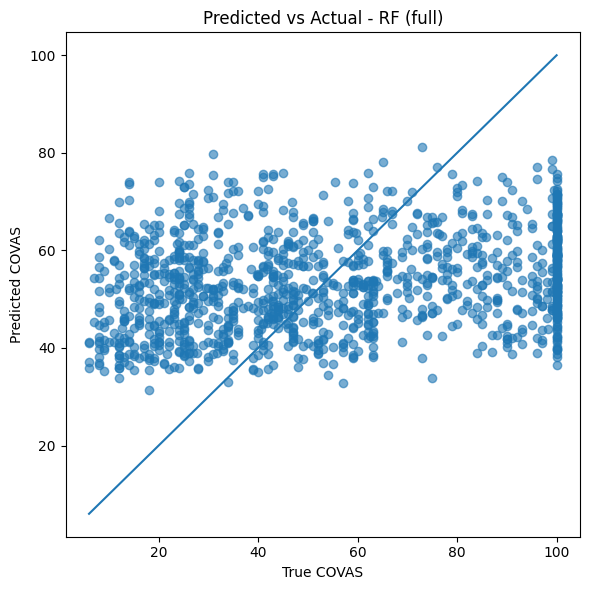

In [ ]:
plot_predicted_vs_actual(y_test, y_pred_rf, model_name="RF", feature_set="full")

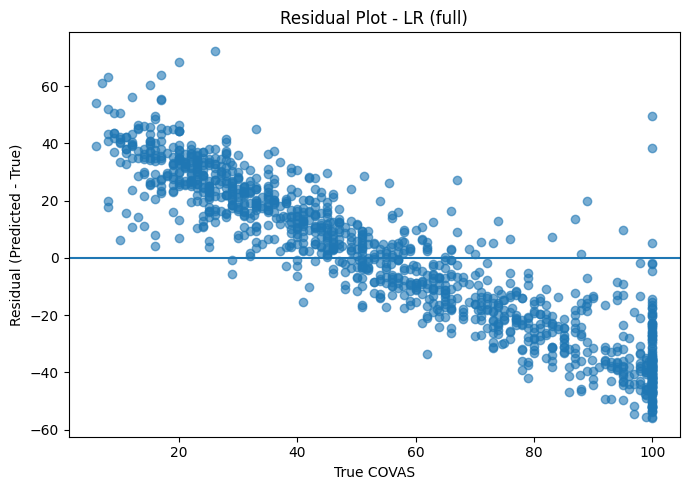

In [ ]:
plot_residuals(y_test, y_pred_lr, model_name="LR", feature_set="full")

### LINEAR REGRESSION ASSUMPTIONS

1. Residues follow a **normal distribution**
2. Residues have **zero mean** and **constant variance**
3. Residues are **independent** (aka no real structure)
4. **Linearity**  (check resiudals vs fitted values)

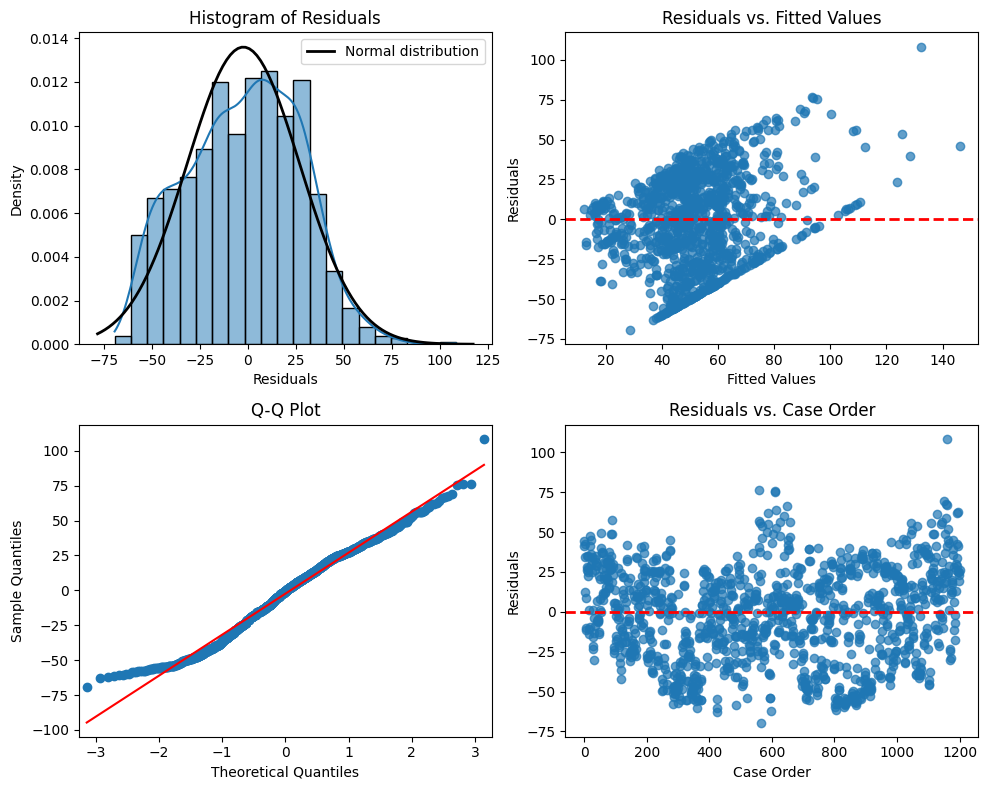

In [ ]:
residual_analysis(y_test, y_pred_lr)

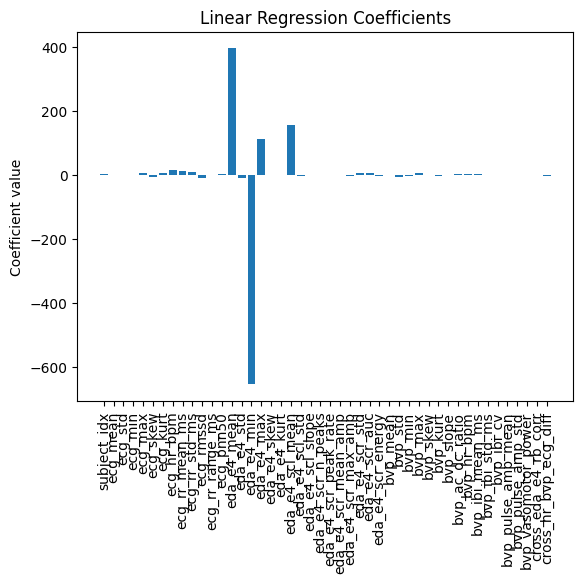

In [ ]:
plot_lr_coefficients(pipeline_lr, feature_names=WEARABLE_FEATURES)

Best n_features: 14
Best R²: 0.0608


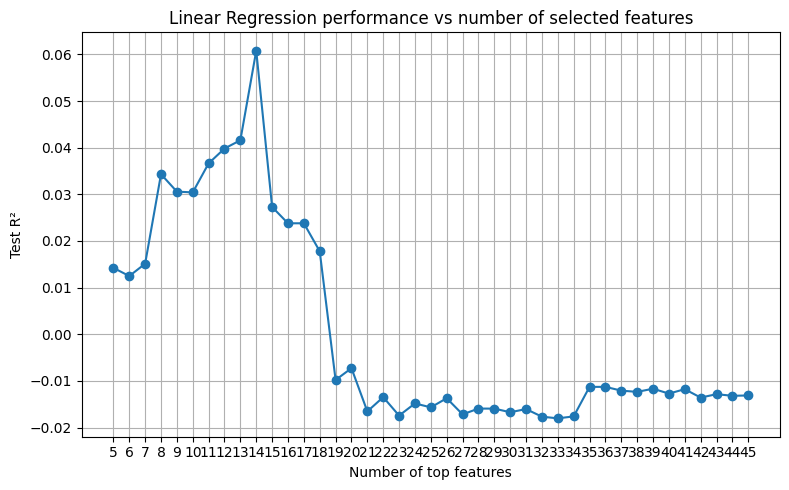

In [10]:
r2_scores = []
n_features_list = list(range(5, X_train.shape[1]))

for i in n_features_list:
    top_features, importance_df = get_top_features_lr(
        model=pipeline_lr,
        X_train=X_train,
        y_train=y_train,
        n_top=i
    )

    X_train_top, X_test_top = select_top_features(X_train, X_test, top_features)
    top_lr_pipeline = create_LR_pipeline()
    metrics_lr, y_pred_lr = train_and_evaluate(
        top_lr_pipeline, X_train_top, y_train, X_test_top, y_test
    )
    r2_scores.append(metrics_lr["R2"])
best_idx = max(range(len(r2_scores)), key=lambda j: r2_scores[j])
best_n = n_features_list[best_idx]
best_r2 = r2_scores[best_idx]

print(f"Best n_features: {best_n}")
print(f"Best R²: {best_r2:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(n_features_list, r2_scores, marker='o')
plt.xlabel("Number of top features")
plt.ylabel("Test R²")
plt.title("Linear Regression performance vs number of selected features")
plt.xticks(n_features_list)
plt.grid(True)
plt.tight_layout()
plt.show()

### SVR tunnnig


In [ ]:
grid_svr = tune_SVR(X_train, y_train)
print(grid_svr.best_params_)
best_svr = grid_svr.best_estimator_
print(grid_svr.best_score_)

KeyboardInterrupt: 

In [ ]:
metrics_best_svr,y_pred_best_svr=train_and_evaluate(best_svr, X_train, y_train, X_test, y_test)
print("Tuned SVR Metrics:", metrics_best_svr)

Tuned SVR Metrics: {'MSE': 706.1410651370447, 'R2': 0.3522975106550632, 'RMSE': np.float64(26.57331490682043), 'MAE': 20.99677714079062}


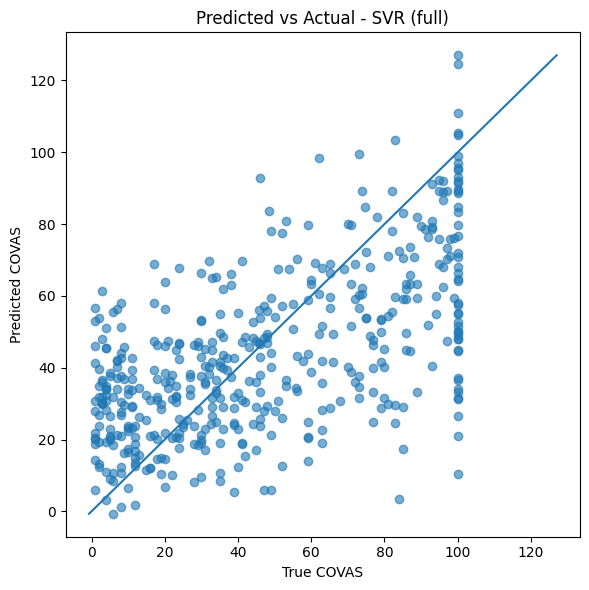

In [ ]:
plot_predicted_vs_actual(y_test, y_pred_best_svr, model_name="SVR", feature_set="full")

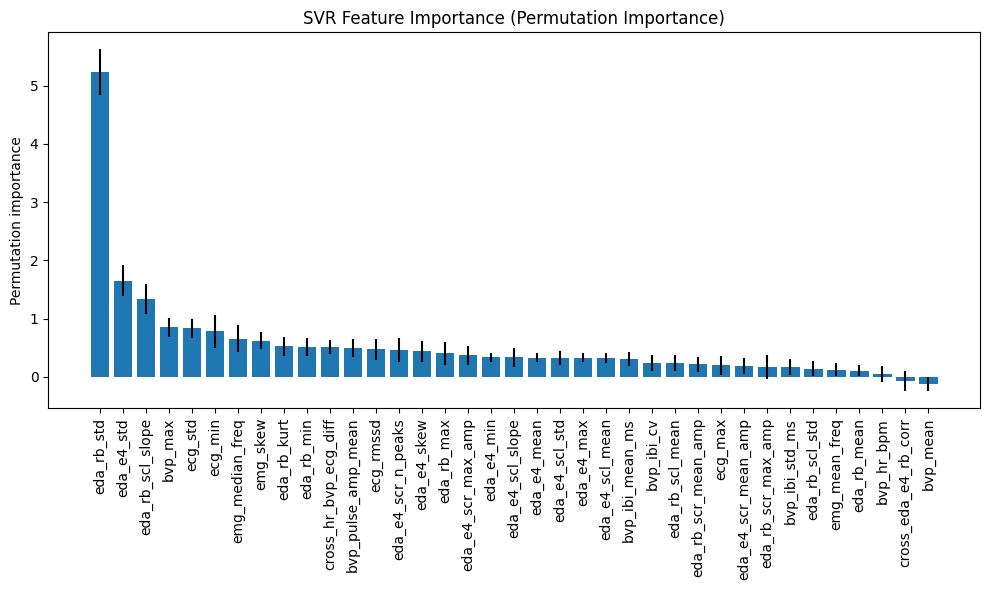

In [ ]:

plot_svr_permutation_importance(
    best_svr,
    X_test,
    y_test,
    FULL_FEATURES
)


In [ ]:
"""
importance_df = compute_permutation_importance_df(
    pipeline=best_svr,
    X=X_train,
    y=y_train,
    feature_names=X_train.columns,
    n_repeats=10
)

top_15_features = get_top_features_from_importance(
    importance_df,
    n_top=15,
    only_positive=True   
)

print("Top 15 features:")
print(top_15_features)

importance_df.head(15)
"""

'\nimportance_df = compute_permutation_importance_df(\n    pipeline=best_svr,\n    X=X_train,\n    y=y_train,\n    feature_names=X_train.columns,\n    n_repeats=10\n)\n\ntop_15_features = get_top_features_from_importance(\n    importance_df,\n    n_top=15,\n    only_positive=True   \n)\n\nprint("Top 15 features:")\nprint(top_15_features)\n\nimportance_df.head(15)\n'

In [ ]:
#X_train_top15 = X_train[top_15_features].copy()
#X_test_top15  = X_test[top_15_features].copy()

In [ ]:
"""
grid_svr_top15 = tune_SVR(X_train_top15, y_train, PCA_n_components=None)
print(grid_svr_top15.best_params_)
print(grid_svr_top15.best_score_)

best_svr_top15 = grid_svr_top15.best_estimator_
"""

'\ngrid_svr_top15 = tune_SVR(X_train_top15, y_train, PCA_n_components=None)\nprint(grid_svr_top15.best_params_)\nprint(grid_svr_top15.best_score_)\n\nbest_svr_top15 = grid_svr_top15.best_estimator_\n'

### Random Forest tunning

Best n_features: 17
Best R²: 0.0587


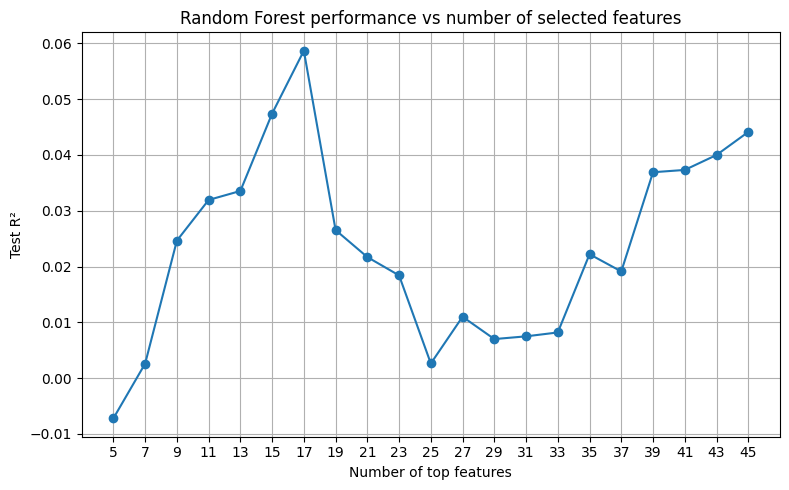

In [11]:
pipeline_rf = create_RF_pipeline(
    n_estimators=50,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt"
)

pipeline_rf.fit(X_train, y_train)

rf_model = pipeline_rf.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": rf_model.feature_importances_
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

ranked_features = importance_df["feature"].tolist()

r2_scores = []
n_features_list = list(range(5, X_train.shape[1], 2))  # fewer evaluations

for i in n_features_list:
    top_features = ranked_features[:i]
    X_train_top, X_test_top = select_top_features(X_train, X_test, top_features)

    top_rf_pipeline = create_RF_pipeline(
        n_estimators=50,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt"
    )

    metrics_rf, y_pred_rf = train_and_evaluate(
        top_rf_pipeline,
        X_train_top, y_train,
        X_test_top, y_test
    )

    r2_scores.append(metrics_rf["R2"])

best_idx = max(range(len(r2_scores)), key=lambda j: r2_scores[j])
best_n = n_features_list[best_idx]
best_r2 = r2_scores[best_idx]

print(f"Best n_features: {best_n}")
print(f"Best R²: {best_r2:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(n_features_list, r2_scores, marker='o')
plt.xlabel("Number of top features")
plt.ylabel("Test R²")
plt.title("Random Forest performance vs number of selected features")
plt.xticks(n_features_list)
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
top_features = ranked_features[:best_n]
X_train_top, X_test_top = select_top_features(X_train, X_test, top_features)

top_rf_pipeline = create_RF_pipeline(
)

metrics_rf, y_pred_rf = train_and_evaluate(
    top_rf_pipeline,
    X_train_top, y_train,
    X_test_top, y_test
)
print(f"RF with top {best_n} features - R²: {metrics_rf['R2']:.4f}, MAE: {metrics_rf['MAE']:.4f}, MSE: {metrics_rf['MSE']:.4f}")

RF with top 17 features - R²: 0.0045, MAE: 21.3638, MSE: 667.1626


In [ ]:
grid_rf = tune_RF(X_train_top, y_train)

print(grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
print(grid_rf.best_score_)

{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
0.3486393238928443


In [ ]:
metrics_best_rf,y_pred_best_rf=train_and_evaluate(best_rf, X_train, y_train, X_test, y_test)
print("Tuned RF Metrics:", metrics_best_rf)

Tuned RF Metrics: {'MSE': 517.9219572931472, 'R2': 0.3704461617136702, 'RMSE': np.float64(22.757898789061066), 'MAE': 19.219551155821918}


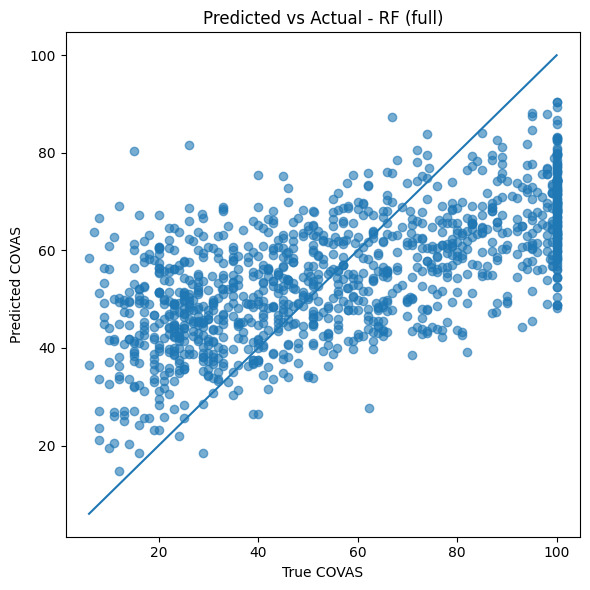

In [ ]:
plot_predicted_vs_actual(y_test, y_pred_best_rf, model_name="RF", feature_set="full")

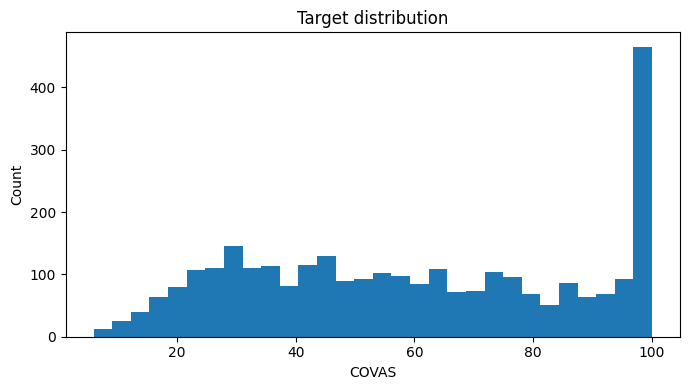

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(y_train, bins=30)
plt.xlabel("COVAS")
plt.ylabel("Count")
plt.title("Target distribution")
plt.tight_layout()
plt.show()

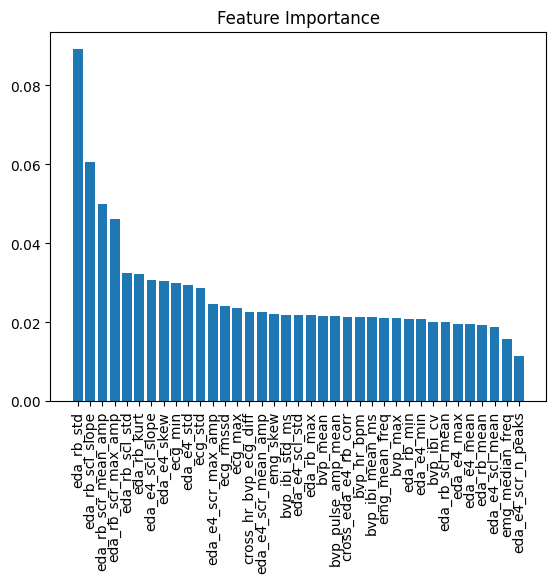

In [ ]:
plot_feature_importance_rf(best_rf, feature_names=FULL_FEATURES)

## XGBOOST

Best n_features: 18
Best R²: -0.0938


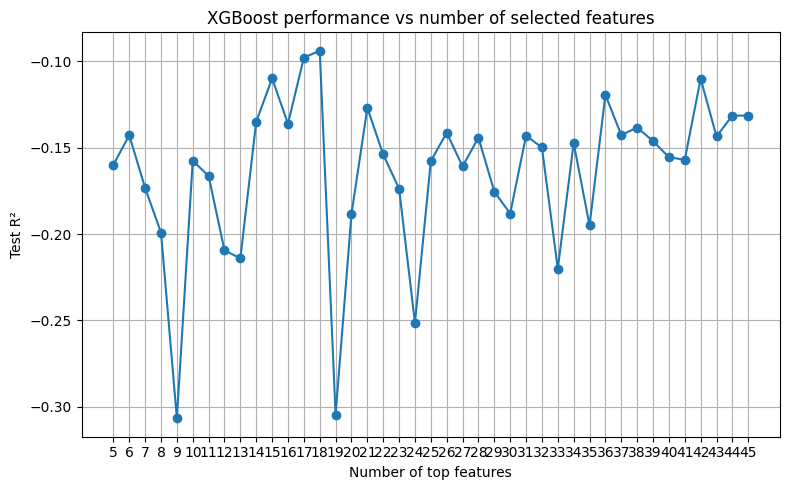

In [13]:
r2_scores=[]
n_features_list = list(range(5, X_train.shape[1]))
for i in n_features_list:

    top_features, importance_df = get_top_features_xgb(
        model=pipeline_xgboost,
        X_train=X_train,
        y_train=y_train,
        n_top=i,
        scoring="r2"
    )

    X_train_top, X_test_top = select_top_features(X_train, X_test, top_features)
    top_xgboost_pipeline=create_XGBOOST_pipeline()
    metrics_xgboost,y_pred_xgboost=train_and_evaluate(top_xgboost_pipeline,X_train_top,y_train,X_test_top,y_test)
    r2_scores.append(metrics_xgboost["R2"])


best_idx = max(range(len(r2_scores)), key=lambda j: r2_scores[j])
best_n = n_features_list[best_idx]
best_r2 = r2_scores[best_idx]

print(f"Best n_features: {best_n}")
print(f"Best R²: {best_r2:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(n_features_list, r2_scores, marker='o')
plt.xlabel("Number of top features")
plt.ylabel("Test R²")
plt.title("XGBoost performance vs number of selected features")
plt.xticks(n_features_list)
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
top_features, importance_df = get_top_features_xgb(
        model=pipeline_xgboost,
        X_train=X_train,
        y_train=y_train,
        n_top=best_n,
        scoring="r2"
    )
print("Top features for XGBoost:")
print(top_features)
x_train_top, x_test_top = select_top_features(X_train, X_test, top_features)
top_xgboost_pipeline=create_XGBOOST_pipeline()
metrics_xgboost,y_pred_xgboost=train_and_evaluate(top_xgboost_pipeline,x_train_top,y_train,x_test_top,y_test)
print(f"XGBoost with top {best_n} features - R²: {metrics_xgboost['R2']:.4f}, MAE: {metrics_xgboost['MAE']:.4f}, MSE: {metrics_xgboost['MSE']:.4f}")

Top features for XGBoost:
['eda_e4_std', 'bvp_min', 'eda_e4_min', 'cross_eda_e4_rb_corr', 'eda_e4_scl_std', 'subject_idx', 'ecg_min', 'eda_e4_scr_auc', 'ecg_max', 'eda_e4_scl_slope', 'ecg_mean', 'bvp_pulse_amp_std', 'eda_e4_mean', 'eda_e4_skew', 'ecg_std', 'ecg_rr_std_ms', 'eda_e4_scl_mean', 'ecg_rmssd']
XGBoost with top 18 features - R²: -0.0938, MAE: 21.1801, MSE: 733.0579


In [ ]:

X_train_top, X_test_top = select_top_features(X_train, X_test, top_features)
grid_xgboost = tune_XGBOOST(X_train_top, y_train,random=False, random_iter=500)

print(grid_xgboost.best_params_)
best_xgboost = grid_xgboost.best_estimator_
print(grid_xgboost.best_score_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__min_child_weight': 1, 'model__n_estimators': 500, 'model__reg_lambda': 6.0, 'model__subsample': 0.8}
0.34604664264766805
